# 13 · Aerodynamics: three interchangeable models, the tiltrotor extras, and cruise closure

`aerodynamics/` (738 lines) holds three whole-aircraft models with one interface, plus three tiltrotor-specific pieces:

| Module | What |
|---|---|
| `simple.py` | `SimpleAerodynamics`: linear lift, component parasite build-up (AeroSandbox skin friction and form factors), Oswald induced drag |
| `scholz.py` | `ScholzAerodynamics`: Scholz's level-0 hand build-up (Mach-corrected friction, Torenbeek wetted areas, interference, Korn wave drag, Nita-Scholz Oswald), the independent check |
| `buildup.py` | `BuildupAerodynamics`: AeroSandbox `AeroBuildup` with NeuralFoil section polars, plus interference, excrescence, gear, trim and blown-wing items: the Halo reference |
| `slipstream.py` | `BlownWing`: rotor slipstream increments on the wing in airplane mode |
| `trim.py` | `TailTrim`: trim drag from the tail load that zeroes the pitching moment |
| `download.py` | `HoverDownload`: fraction of hover thrust lost on the wing under the rotor wake |

This notebook runs each on the same aircraft, takes the drag build-ups apart, shows the three extras, and closes mass with a cruise
equilibrium (`examples/cruise_closure.py`), the third rung of the ladder.

**In this notebook**
1. The interface every model implements.
2. `SimpleAerodynamics`: lift, parasite build-up, induced drag; the drag polar.
3. `ScholzAerodynamics`: what changes and why it exists.
4. `BuildupAerodynamics`: AeroBuildup plus the items it lacks; cost.
5. The three models side by side.
6. Blown wing, trim drag, hover download.
7. Cruise closure: mass, CG and lift = weight in one Opti, with L/D feeding the fuselage correlation.

**Run time:** about 10 seconds.

In [1]:
from tutorial_helpers import *
import numpy as onp
import inspect
from dataclasses import replace
from aircraft_closure.aerodynamics.simple import SimpleAerodynamics, DragIncrement
from aircraft_closure.aerodynamics.scholz import ScholzAerodynamics, InterferenceFactors
from aircraft_closure.aerodynamics.buildup import BuildupAerodynamics
from aircraft_closure.aerodynamics.slipstream import BlownWing, RotorState
from aircraft_closure.aerodynamics.download import HoverDownload, download_fraction
from examples.aircraft_mass_closure import build_reference_aircraft
aircraft = build_reference_aircraft(x_le_wing_m=3.2, mass_payload_kg=300.0, count_rotors=4)

## 1. The interface

Every model implements the same methods, so the flight point (tutorial 15) never knows which one it has:

| Method | Returns |
|---|---|
| `evaluate(aircraft, velocity_m_s, altitude_m, alpha_deg, drag_increments=(), temperature_offset_K=0.0, rotor_state=None)` | `AeroResult`: alpha, CL, CD, CD0, CDi, lift slope, Oswald factor, dynamic pressure, Mach, lift, drag, L/D |
| `alpha_stall_deg(aircraft, velocity, altitude, ..., aero=None)` | the angle at `cl_max`, a caller-side upper bound on alpha |
| `lift_curve_slope_per_rad(...)`, `surface_lift_curve_slope_per_rad(aspect_ratio, ...)` | analytic slopes used by the stability equations (tutorial 14) |
| `hover_download_fraction(aircraft)` | download / thrust in hover |

`alpha_deg` is typically an Opti variable (the flight point creates it), and `aircraft` may be full of design variables, so all of it
must be symbolic. Geometry comes from each component's `to_asb()`: the aerodynamics imports no vehicle module.

In [2]:
simple = SimpleAerodynamics()
result = simple.evaluate(aircraft, velocity_m_s=60.0, altitude_m=1000.0, alpha_deg=4.0)
for name, value in result.__dict__.items():
    print(f"{name:<20}{scalar(value):12.5f}")

alpha_deg                4.00000
cl                       0.70134
cd                       0.06129
cd0                      0.03840
cdi                      0.02289
cl_alpha_per_rad         5.02300
oswald_efficiency        0.76002
dynamic_pressure_Pa   1999.47669
mach                     0.17827
lift_N               16827.83460
drag_N                1470.65457
lift_to_drag            11.44241


## 2. `SimpleAerodynamics`

- **Lift**: $C_L = a\,(\alpha - \alpha_0)$, $a = 2\pi \cdot$ `CL_over_Cl(AR, M)` (AeroSandbox's finite-wing correction), $\alpha_0 = -4°$.
  Wing lift only (tail lift belongs to trim, tutorial 14). Valid in attached flow below `cl_max`.
- **Parasite**: for each component, $C_f(\mathrm{Re})\cdot FF \cdot Q \cdot S_\text{wet}/S_\text{ref}$, with AeroSandbox's flat-plate friction, the
  Raymer surface form factor and AeroSandbox's fuselage form factor, plus a miscellaneous drag area.
- **Induced**: $C_L^2/(\pi e A)$, $e$ from AeroSandbox's `oswalds_efficiency` with the fuselage-to-span ratio.

In [3]:
breakdown = simple.parasite_drag_breakdown(aircraft, 60.0, 1000.0)
total_cd0 = sum(item.cd0 for item in breakdown)
for item in breakdown:
    print(f"{item.label:<16}{item.cd0:9.5f}   {item.cd0 / total_cd0:5.1%}")
print(f"{'CD0':<16}{total_cd0:9.5f}")
check("the build-up sums to the CD0 the model reports", abs(total_cd0 - result.cd0) < 1e-12)

wing              0.00980   25.5%
horizontal_tail   0.00184    4.8%
vertical_tail     0.00117    3.1%
fuselage          0.00476   12.4%
miscellaneous     0.02083   54.2%
CD0               0.03840
PASS  the build-up sums to the CD0 the model reports


`drag_increments` is the extension hook: any additive `DragIncrement(label, cd)` on the wing reference area, such as the tail's trim drag
from `LongitudinalStability` (tutorial 14). A sweep in alpha gives the polar:

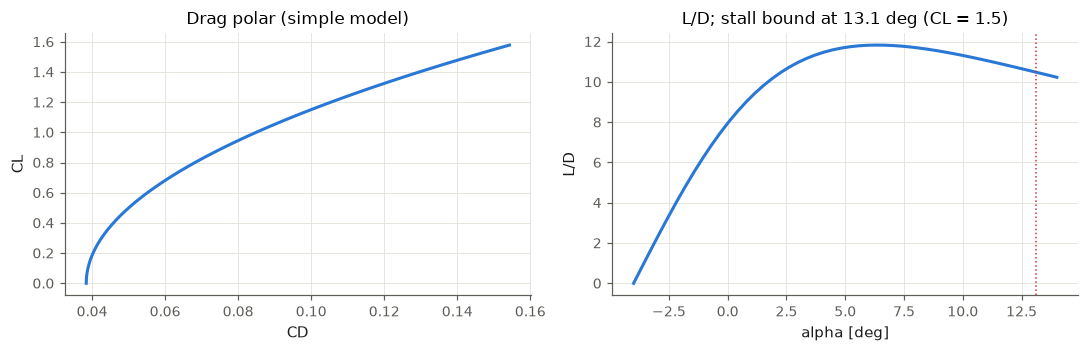

max L/D 11.83 at CL 0.902; parabolic-polar theory: L/D_max = 11.83 at CL = 0.908


In [4]:
alphas = onp.linspace(-4, 14, 50)
polar = [simple.evaluate(aircraft, 60.0, 1000.0, a) for a in alphas]
cl = onp.array([scalar(p.cl) for p in polar]); cd = onp.array([scalar(p.cd) for p in polar])
alpha_stall = scalar(simple.alpha_stall_deg(aircraft, 60.0, 1000.0))
fig, axes = plt.subplots(1, 2, figsize=(10, 3.3))
axes[0].plot(cd, cl, color=blue, lw=2); axes[0].set(xlabel="CD", ylabel="CL", title="Drag polar (simple model)")
axes[1].plot(alphas, cl / cd, color=blue, lw=2); axes[1].axvline(alpha_stall, color=red, ls=":", lw=1)
axes[1].set(xlabel="alpha [deg]", ylabel="L/D", title=f"L/D; stall bound at {alpha_stall:.1f} deg (CL = {simple.cl_max})")
plt.tight_layout(); plt.show()
k = onp.argmax(cl / cd)
cd0_, e_, A_ = scalar(polar[0].cd0), scalar(polar[0].oswald_efficiency), aircraft.wing.aspect_ratio
print(f"max L/D {cl[k] / cd[k]:.2f} at CL {cl[k]:.3f}; parabolic-polar theory: L/D_max = {0.5 * onp.sqrt(onp.pi * e_ * A_ / cd0_):.2f} at CL = {onp.sqrt(onp.pi * e_ * A_ * cd0_):.3f}")

## 3. `ScholzAerodynamics`: the hand check

Scholz's level-0 method (*Aircraft Design*, ch. 13) extends `SimpleAerodynamics`, keeping its linear lift. It changes:

- friction with a Mach term, $0.455 / (\log_{10}\mathrm{Re}^{2.58}(1 + 0.144M^2)^{0.65})$ (AeroSandbox's has none);
- Torenbeek wetted areas (exposed wing area, fuselage with a cylindrical mid-section);
- Scholz Table 13.4 interference factors (`InterferenceFactors`: tip nacelles 1.5, tails 1.04);
- nacelles as bodies, fixed landing gear as a drag area (the reference aircraft's gear is fixed), an excrescence factor;
- Korn wave drag; Nita-Scholz Oswald factor with the turboprop $k_{e,D0}$ and a Mach factor.

It exists as an **independent check** of the AeroBuildup model, and it is the fast option for studies (within about 1 % in mass of the
reference, per the electrical-layer tests).

In [5]:
scholz = ScholzAerodynamics()
for item in scholz.parasite_drag_breakdown(aircraft, 60.0, 1000.0):
    print(f"{item.label:<16}{item.cd0:9.5f}")
print(f"CD0 simple {total_cd0:.5f} vs Scholz {sum(i.cd0 for i in scholz.parasite_drag_breakdown(aircraft, 60.0, 1000.0)):.5f}")

wing              0.00914
horizontal_tail   0.00197
vertical_tail     0.00124
fuselage          0.00580
miscellaneous     0.00000
landing_gear      0.04359
CD0 simple 0.03840 vs Scholz 0.06173


The large difference here is mostly the fixed landing gear (5.63 ft² of drag area, NDARC's UH-60A value), which the simple model only
represents through its miscellaneous drag area. Different models, different inventories of drag: always read the breakdown.

## 4. `BuildupAerodynamics`

Runs `asb.AeroBuildup` on `aircraft.to_asb()`: wing and tails with **NeuralFoil** section polars (a neural-network airfoil model, so viscous
drag responds to Reynolds number, Mach and lift, including post-stall), bodies with AeroSandbox's form factors, and the induced drag of the
whole aircraft's lift. On top it adds what AeroBuildup leaves out: a 10 % chord transition location (NeuralFoil otherwise sees no
transition), interference (Q − 1) × profile drag, the Nita-Scholz fuselage and Mach factors on Oswald, a miscellaneous drag area, fixed gear,
an excrescence factor (1.27, calibrated so the XV-15 matches NDARC's 6.25 ft²), trim drag from `TailTrim`, blown-wing increments, and
geometric hover download.

It is a **pure function of AeroSandbox numpy**, so it differentiates like everything else, but it is far heavier: every flight point carries
a neural net per wing section in its expression graph, so the NLP is much larger and slower to differentiate (a single numeric evaluation, below, is quick). That is why it dominates the Halo reference's run time and why studies often switch to Scholz.

In [6]:
import time
buildup = BuildupAerodynamics()
time_start_s = time.perf_counter()
detail = buildup.evaluate_buildup(aircraft, 60.0, 1000.0, 4.0)
print(f"one numeric AeroBuildup evaluation: {time.perf_counter() - time_start_s:.2f} s")
for item in detail.breakdown:
    print(f"{item.label:<20}{scalar(item.cd0):9.5f}")
print(f"CL {scalar(detail.aero.cl):.4f} (AeroBuildup {scalar(detail.cl_aerobuildup):.4f}), CD {scalar(detail.aero.cd):.5f}, "
      f"Oswald {scalar(detail.aero.oswald_efficiency):.3f}")

one numeric AeroBuildup evaluation: 0.09 s
wing                  0.01041
horizontal_tail       0.00185
vertical_tail         0.00114
fuselage              0.00479
miscellaneous         0.00000
landing_gear          0.04359
CL 0.8495 (AeroBuildup 0.8495), CD 0.09535, Oswald 0.760


## 5. The three models side by side

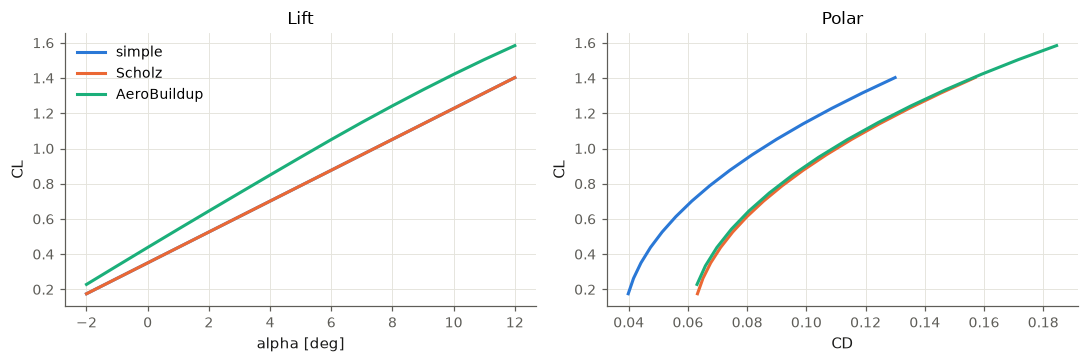

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
for model, label, color in ((simple, "simple", blue), (scholz, "Scholz", orange), (buildup, "AeroBuildup", aqua)):
    alphas_ = onp.linspace(-2, 12, 15)
    results = [model.evaluate(aircraft, 60.0, 1000.0, a) for a in alphas_]
    cl_ = onp.array([scalar(r.cl) for r in results]); cd_ = onp.array([scalar(r.cd) for r in results])
    axes[0].plot(alphas_, cl_, color=color, lw=2, label=label)
    axes[1].plot(cd_, cl_, color=color, lw=2, label=label)
axes[0].set(xlabel="alpha [deg]", ylabel="CL", title="Lift"); axes[1].set(xlabel="CD", ylabel="CL", title="Polar")
axes[0].legend(); plt.tight_layout(); plt.show()

AeroBuildup's lift includes the tails and fuselage and NeuralFoil's real section slopes and zero-lift angle (the NACA 4418 is cambered), so
its lift curve differs from the linear model's. Its drag sits close to Scholz once the same inventory (gear) is present.

## 6. Tiltrotor extras

### Blown wing

In airplane mode the proprotor slipstream washes the inboard half of each tip rotor's disk over the wing. `BlownWing.evaluate` uses momentum
theory for the induced velocity, McCormick's growth to the wing, continuity for the slipstream radius, and returns increments on the
immersed span: a higher dynamic pressure (more lift and profile drag there), a swirl angle, and a **swirl recovery** (the wing acting as a
stator turns some of the swirl back into thrust: a negative drag increment). Every increment is zero at zero thrust.

In [8]:
blown = BlownWing()
for thrust_N in (0.0, 4000.0, 8000.0):
    inc = blown.evaluate(velocity_m_s=85.0, density_kg_m3=0.9, rotor_state=RotorState(thrust_N, 45.0), area_disk_m2=70.0,
                         count_rotors=2, chord_wing_m=2.3, area_wing_m2=23.0, cl_wing=0.45, cd_profile_wing=0.009,
                         cl_alpha_wing_per_rad=4.8)
    print(f"thrust {thrust_N:6.0f} N/rotor: q ratio {scalar(inc.ratio_dynamic_pressure):.3f}, swirl {scalar(inc.angle_swirl_deg):5.2f} deg, "
          f"dCL {scalar(inc.delta_cl):+.4f}, dCD profile {scalar(inc.delta_cd_profile):+.5f}, dCD swirl {scalar(inc.delta_cd_swirl):+.5f}")

thrust      0 N/rotor: q ratio 1.000, swirl  0.00 deg, dCL +0.0000, dCD profile +0.00000, dCD swirl -0.00000
thrust   4000 N/rotor: q ratio 1.012, swirl  0.30 deg, dCL +0.0291, dCD profile +0.00010, dCD swirl -0.00009
thrust   8000 N/rotor: q ratio 1.024, swirl  0.60 deg, dCL +0.0585, dCD profile +0.00020, dCD swirl -0.00034


The coupling is circular: the slipstream depends on thrust, thrust equals drag, drag depends on the slipstream. The flight point resolves it
**without iteration**: thrust per rotor becomes a variable inside `RotorState`, and an equality ties it to the drag (tutorial 15).

### Trim drag

`TailTrim` (Scholz ch. 11) takes AeroBuildup's whole-aircraft pitching moment about the CG, corrects it for the wing downwash AeroBuildup does
not model at the tail, finds the tail lift increment that zeroes it, and charges the tail's induced drag plus the change in the wing's induced
drag. With the Scholz model, a simpler fraction (2 % of parasite + induced) is used instead.

### Hover download

In hover the wake hits the wing below the rotor. NDARC's form: $DL/T = K\,C_{D,v}\,S_\text{immersed}/A_\text{disk}$, the immersed strip
under the inboard half of each contracted wake (radius $R/\sqrt 2$) with the flap-projected chord. $C_{D,v} = 0.846$ reproduces the XV-15's
7 % download with flaps:

XV-15 download: 0.0700
PASS  the calibration reproduces the XV-15's 7 % hover download


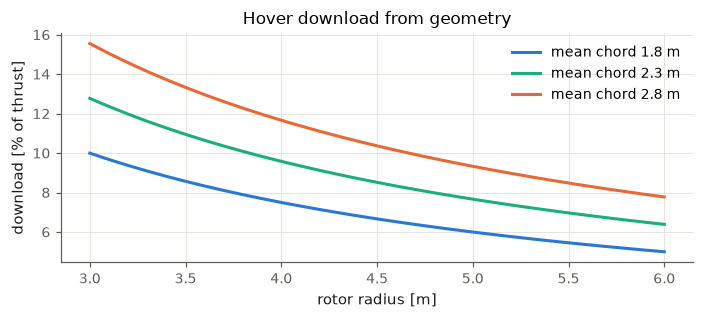

In [9]:
xv15 = download_fraction(chord_wing_m=168.88 * u.foot**2 / (32.17 * u.foot), radius_rotor_m=12.5 * u.foot, count_rotors=2)
print(f"XV-15 download: {xv15:.4f}")
check("the calibration reproduces the XV-15's 7 % hover download", abs(xv15 - 0.07) < 1e-3)
radii = onp.linspace(3.0, 6.0, 31)
fig, ax = plt.subplots(figsize=(6.5, 3.0))
for chord_m, color in ((1.8, blue), (2.3, aqua), (2.8, orange)):
    ax.plot(radii, [download_fraction(chord_m, r, 2) * 100 for r in radii], color=color, lw=2, label=f"mean chord {chord_m} m")
ax.set(xlabel="rotor radius [m]", ylabel="download [% of thrust]", title="Hover download from geometry")
ax.legend(); plt.tight_layout(); plt.show()

In the flight point the hover thrust per rotor is $(T/W)\,W / ((1 - DL/T)\,n_\text{rotors})$: the download is a design-dependent penalty on every
hover (a wider wing chord costs hover power).

## 7. Cruise closure

Extend tutorial 12's closure with a cruise point: the angle of attack is a variable; lift = weight is an equality; alpha stays below stall;
and the **solved** L/D feeds the fuselage mass correlation. Aerodynamics and weights are now coupled both ways, in one problem. This is
`solve_cruise_closure`, run with each model:

In [10]:
from examples.cruise_closure import solve_cruise_closure
print(inspect.getsource(solve_cruise_closure)[:2200])

def solve_cruise_closure(velocity_cruise_m_s=60.0, altitude_cruise_m=1000.0, mass_payload_kg=300.0,
                         cg_fraction_mac=0.25, aerodynamics=None):
    aerodynamics = aerodynamics or SimpleAerodynamics()
    opti = asb.Opti()
    mass_takeoff_kg = opti.variable(init_guess=1550, lower_bound=100)
    x_le_wing_m = opti.variable(init_guess=3.2, lower_bound=0.5, upper_bound=5.5)
    alpha_cruise_deg = opti.variable(init_guess=3, lower_bound=-5, upper_bound=20)
    aircraft = build_reference_aircraft(x_le_wing_m, mass_payload_kg)
    cruise = aerodynamics.evaluate(aircraft, velocity_cruise_m_s, altitude_cruise_m, alpha_cruise_deg)
    condition = StructuralDesignCondition(mass_design_kg=mass_takeoff_kg, velocity_cruise_m_s=velocity_cruise_m_s,
                                          altitude_cruise_m=altitude_cruise_m, lift_to_drag_cruise=cruise.lift_to_drag)
    breakdown = aircraft.get_mass_breakdown(condition)
    total = breakdown.total()
    chord_mac_m = aircraft.

In [11]:
rows = []
for model, label in ((simple, "simple"), (scholz, "Scholz"), (buildup, "AeroBuildup")):
    time_start_s = time.perf_counter()
    r = solve_cruise_closure(aerodynamics=model)
    rows.append((label, r, time.perf_counter() - time_start_s))
    print(f"{label:<12} MTOM {r.mass_takeoff_kg:8.1f} kg, alpha {r.alpha_cruise_deg:5.2f} deg, CL {r.cl_cruise:.3f}, L/D {r.lift_to_drag_cruise:5.2f}, "
          f"drag power {r.power_drag_cruise_W / 1e3:5.1f} kW   [{rows[-1][2]:.1f} s]")
check("every closure satisfies lift = weight", all(abs(r.lift_residual_N) < 1e-4 for _, r, _ in rows))

simple       MTOM   1552.9 kg, alpha  3.24 deg, CL 0.635, L/D 11.11, drag power  82.3 kW   [0.2 s]
Scholz       MTOM   1555.3 kg, alpha  3.25 deg, CL 0.636, L/D  7.82, drag power 117.0 kW   [0.1 s]


AeroBuildup  MTOM   1555.2 kg, alpha  1.91 deg, CL 0.636, L/D  7.95, drag power 115.2 kW   [1.9 s]
PASS  every closure satisfies lift = weight


Mass hardly changes here because this example's powertrain is fixed: drag only enters the fuselage correlation (weakly, through L/D). Once the
powertrain is sized to fly the aircraft (tutorials 16-18), drag drives everything.

## Summary

- One interface (`evaluate`, `alpha_stall_deg`, slopes, download) and three models: simple, Scholz (the hand check, fast), AeroBuildup with
  NeuralFoil (the reference, heavy).
- Drag is a component build-up; always read the breakdown, since the models carry different inventories (gear, nacelles, excrescence, trim).
- Tiltrotor extras: blown wing (coupled through a thrust variable, no iteration), trim drag from the tail load, hover download from geometry.
- Cruise closure adds alpha as a variable and lift = weight as an equality; L/D couples back into the mass correlations.

## Check yourself

<details><summary>1. Why does <code>BuildupAerodynamics.alpha_stall_deg</code> accept the point's <code>aero</code> result?</summary>

With it, the stall bound is $\alpha + (C_{L,max} - C_L)/C_{L\alpha}$ at the point, so "alpha ≤ alpha_stall" is exactly "CL ≤ cl_max" with no extra AeroBuildup runs. Without it, the model linearizes its own lift curve through two reference angles (two more runs per call).
</details>

<details><summary>2. A study switches from AeroBuildup to Scholz and the take-off mass changes by 1 %. Is that a bug?</summary>

No: they are different models with documented differences (section 3), and about 1 % is the expected size of that difference. Compare their breakdowns at the same point to see where it comes from.
</details>

In [12]:
check_summary()

3 of 3 checks passed
